###Heart Rate Estimation from NIR Facial Videos


In [1]:
##1. Import libraries

In [2]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from scipy.signal import butter, filtfilt, find_peaks
from scipy.ndimage import gaussian_filter1d

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

In [3]:
# Load NIR Frames

In [4]:
folder_path = folder_path = "C:\\Users\\Lenovo\\OneDrive\\Desktop\\heart_rate_project\\sample_data\\Subject1\\NIR-002"

files = sorted(os.listdir(folder_path))
print(f"Total frames found: {len(files)}")

Total frames found: 1500


In [5]:
# 3. Preprocessing + ROI extraction
signal = []
max_frames = 1500
for file in files[:max_frames]:

    if file.lower().endswith(".pgm"):
        path = os.path.join(folder_path, file)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            print(f"Warning: Could not read {file}")
            continue
    #resize image
    img = cv2.resize(img, (256, 256))
    h,w = img.shape

    # fixed forehead ROI
    forehead = img[ h//8 : h//3, w//3 : 2*w//3]

    avg_intensity = np.mean(forehead)
    signal.append(avg_intensity)

  


In [6]:
# 4. RAW signal Generation

Signal Shape: (1500,)


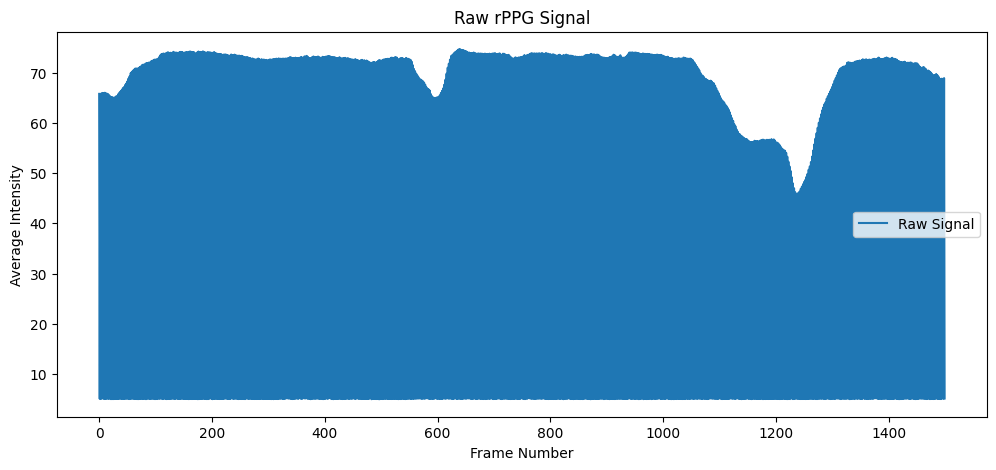

In [7]:
signal = np.array(signal)
print("Signal Shape:", signal.shape)
plt.figure(figsize = (12,5))
plt.plot(signal, label = "Raw Signal")
plt.xlabel("Frame Number")
plt.ylabel("Average Intensity")
plt.title("Raw rPPG Signal")
plt.legend()
plt.show()

In [8]:
# 5. Signal smoothing

In [9]:
signal = gaussian_filter1d(signal, sigma = 2)

In [10]:
# 6. Bandpass filtering

In [11]:
def bandpass_filter(signal, lowcut, highcut, fs, order = 4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype = 'band')
    filtered_signal = filtfilt(b, a, signal)
    return filtered_signal

fs = 30
filtered_signal = bandpass_filter(signal, lowcut = 0.8, highcut = 3.0, fs = fs)

In [12]:
# 7 Filtered signal Visualization

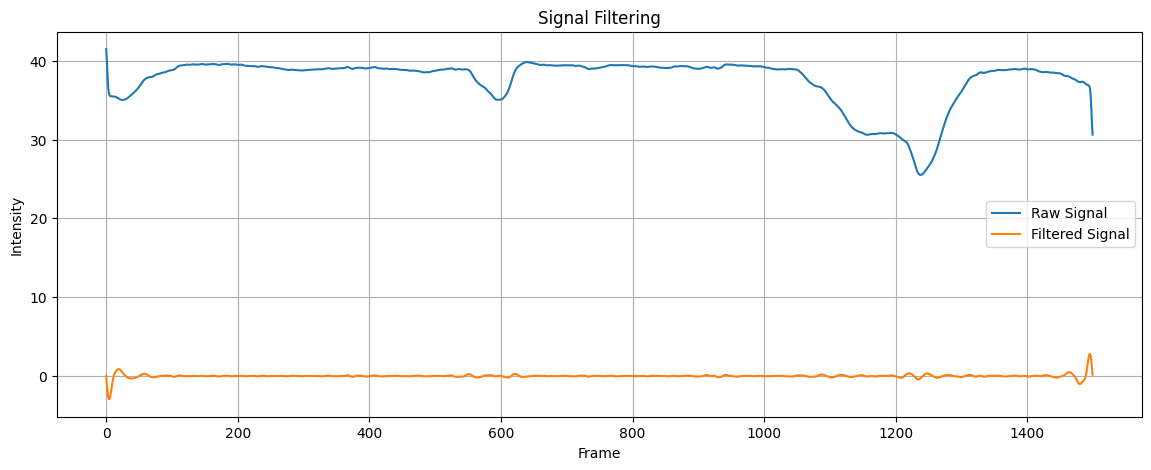

In [14]:
plt.figure(figsize = (14,5))
plt.plot(signal, label = "Raw Signal")
plt.plot(filtered_signal, label = "Filtered Signal")
plt.title("Signal Filtering")
plt.xlabel("Frame")
plt.ylabel("Intensity")
plt.legend()
plt.grid()
plt.show()


In [ ]:
#8 Peak detection
peaks, _ = find_peaks ( filtered_signal, distance = 10)

print("Detected Peaks:", len(peaks))
plt.figure(figsize = (14,5))
plt.plot(filtered_signal, label = "Filtered Signal")
plt.plot(peaks, )